In [35]:
# ! pip install healpy numpyro corner arviz optax reproject einops seaborn

In [2]:
! nvidia-smi --query-gpu=name --format=csv,noheader

zsh:1: command not found: nvidia-smi


In [28]:
import sys
sys.path.append("../")

import torch
from likelihoods.npll_torch import log_like_np
from models.psf import KingPSF
from utils.psf_correction import PSFCorrection
import torch.nn as nn

from jax.config import config
config.update("jax_enable_x64", True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from models.np_model import NPModel

In [33]:
data = jnp.array(np.load("../data/fermi_data/fermidata_counts.npy").astype(np.int32))

npmodel = NPModel(data)

Loading the psf correction from: /Users/smsharma/Projects/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2.npy


## NumPyro

In [4]:
import corner
import arviz as az

In [7]:
mask_ps = np.load("../data/mask_3fgl_0p8deg.npy") == 1

In [16]:
nside = 128
npix = hp.nside2npix(nside)

In [17]:
temp_psc = np.load("../data/fermi_data/template_psc.npy")
temp_iso = np.load("../data/fermi_data/template_iso.npy")
temp_dsk = np.load("../data/fermi_data/template_dsk.npy")
temp_bub = np.load("../data/fermi_data/template_bub.npy")
temp_dsk = np.load("../data/fermi_data/template_dsk.npy")
temp_gce = np.load("../data/fermi_data/template_gce.npy")

# Load Model O templates
temp_mO_pibrem = np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy")
temp_mO_ics = np.load("../data/fermi_data/ModelO_r25_q1_ics.npy")

# Load Model A templates
temp_mA_pibrem = np.load("../data/external/template_Api.npy")
temp_mA_ics = np.load("../data/external/template_Aic.npy")

# Load Model F templates
temp_mF_pibrem = np.load("../data/external/template_Fpi.npy")
temp_mF_ics = np.load("../data/external/template_Fic.npy")

In [18]:
from einops import rearrange
import jax.numpy as jnp
from jax import jit, vmap

### Probabilistic model

In [23]:
data = jnp.array(np.load("../data/fermi_data/fermidata_counts.npy").astype(np.int32))

mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)

k_max = np.max(np.array(data)[~mask_roi])
npixROI = np.prod(len(data[~mask_roi]))

In [24]:
# guide = autoguide.AutoIAFNormal(model, nonlinearity=jax.example_libraries.stax.Tanh, skip_connections=True, hidden_dims=[64, 64], num_flows=4)
guide = autoguide.AutoMultivariateNormal(model)

optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(10.0), optax.adam(5e-3)))

In [25]:
svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=2))
svi_results = svi.run(random.PRNGKey(1), 7500, data, subsample_frac=0.8, r_outer=r_outer, dif=dif)

NameError: name 'bb_hp' is not defined

In [184]:
posterior = guide.sample_posterior(rng_key=random.PRNGKey(0), params=svi_results.params, sample_shape=(50000,))
arviz_post = az.from_dict(posterior)

/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


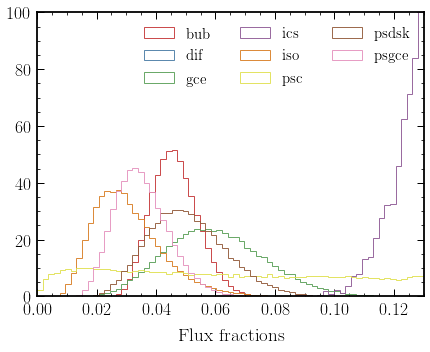

In [185]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])
S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])

flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]

ff_max = 0.13
ff_bins = 70

bins = np.linspace(0, ff_max, ff_bins)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", "")[1:], histtype='step', density=True)
    
plt.xlim(0, ff_max)
plt.ylim(0, 100)
plt.legend(ncol=3, fontsize=15)

plt.xlabel("Flux fractions")

plt.tight_layout()
plt.savefig("prob_prog_results/ff_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

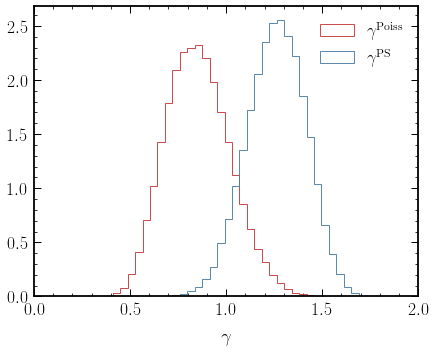

In [186]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])
S_labels = [r"$\gamma^\mathrm{Poiss}$",r"$\gamma^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0.1, 2., 50)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
plt.legend()
plt.xlim(0, 2.)

plt.xlabel(r"$\gamma$")

plt.tight_layout()
plt.savefig("prob_prog_results/gamma_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

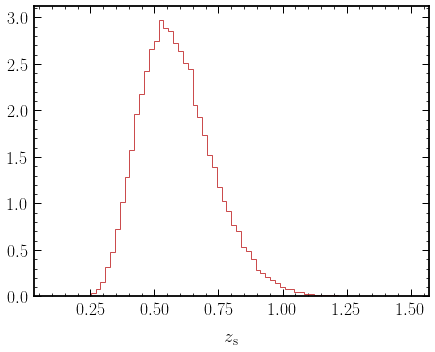

In [187]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])

flux_fraction_post = S_post

bins = np.linspace(0.1, 1.5, 75)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
plt.xlabel("$z_\mathrm{s}$")

plt.tight_layout()
plt.savefig("prob_prog_results/zs_dif_{}_r_{}_lmax_{}_x.pdf".format(dif, r_outer, lmax))

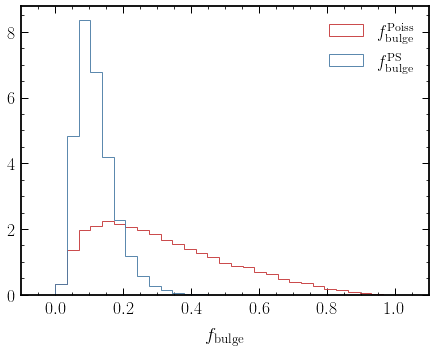

In [188]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])
S_labels = [r"$f_\mathrm{bulge}^\mathrm{Poiss}$",r"$f_\mathrm{bulge}^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0., 1., 30)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i], histtype='step', density=True)
    
plt.xlim(-0.1, 1.1)
plt.legend()

plt.xlabel(r"$f_\mathrm{bulge}$")

plt.tight_layout()
plt.savefig("prob_prog_results/fbulge_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [189]:
# temps_include = ['Sps_gceps', 'S_gce', 'gamma_poiss', 'gamma_ps']
# S_post = np.array([v for k,v  in posterior.items()])
# S_labels = np.array([k for k,v  in posterior.items()])

# corner.corner(S_post.T, labels=[t.replace("_", "") for t in S_labels]);

In [305]:
# corner.corner(arviz_post);

In [95]:
# from numpyro.infer import MCMC, HMCECS, NUTS, Predictive

In [96]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)
# kernel = HMCECS(nuts_kernel, num_blocks=10)

# mcmc = MCMC(kernel, num_samples=4000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, data, subsample_size=int(0.8 * len(data[~mask_roi])))

In [97]:
# arviz_post = az.from_dict(mcmc.get_samples())
# corner.corner(arviz_post);